# INF8775 – Analyse et conception d’algorithmes
# TP1 – Automne 2025

CRUZ PULGARIN, Delany , 2218061

CHIHAB, Ayoub, 2057242

Note finale :

 **Date limite de remise :** 30 septembre (B2)

# Instructions

## Rédaction et remise du rapport

- Ce notebook constitue à la fois le sujet du TP, votre code et votre rapport. Il contient déjà du code pour faciliter vos mesures et l'affichage de vos résultats, ainsi qu'un squelette pour votre rapport.

- Complétez directement le notebook, vous êtes libres de créer de nouvelles cellules de code ou de texte.

- Les questions et tâches à effectuées sont généralement indiquées par un TODO, mais lisez attentivement car nous pourrions avoir oublié d'en indiquer certaines.

- Des questions sont réutilisées d'un algorithme à l'autre (puisque l'on reproduit les expérimentations à des fins de comparaisons). Veillez à suffisament développer les premières réponses afin de l'on comprenne bien votre raisonnement et pour montrer votre bonne compréhension. Vous pourrez être plus concis par la suite.

- Remettez le fichier du notebook sur Moodle avec le nom `NOM1_MATRICULE1_NOM2_MATRICULE2.ipynb`

- Vous pouvez inclure du code trouvé sur Internet, mais vous devez en mentionner la source, sous peine d'être sanctionnés pour plagiat. Cela s'applique aussi au niveau de l'IA générative pour le code. Par contre, vous devez être capable d'accomplir les analyses par vous-même. Vous ne pouvez pas utiliser l'IA pour ces sections.

## Mise en situation

Ce travail pratique se répartit sur deux séances de laboratoire et porte sur l’analyse empirique et hybride des algorithmes. Dans les capsules vidéo de la semaine 3, trois approches d’analyse de l’implantation d’un algorithme sont décrites. Vous les mettrez en pratique pour des algorithmes de résolution d’un problème connu.


## Description du problème

On vous demande de résoudre le problème de la ligne d’horizon (The Skyline Problem) qui consiste à dessiner la silhouette de bâtiments lorsqu’ils sont vus de loin. Ces bâtiments sont juxtaposés l’un à l’autre et il est possible que l’un en cache un autre.

Chaque bâtiment est défini par le triplet `(l, r, h)` avec `h` la hauteur du bâtiment et `l` et `r` les abscisses des murs gauche et droit, respectivement.

La solution représente une suite de couples `(x, h)` représentant les coordonnées des points définissant la silhouette des bâtiments.

Soit l’exemple suivant avec 5 bâtiments :

- L'exemplaire est : `(2, 9, 10), (3, 7, 15), (5, 12, 12), (15, 20, 10),
(19, 24, 8)`
- La solution est : `(2, 10), (3, 15), (7, 12), (12, 0), (15, 10), (20, 8), (24, 0)`

La figure B représente la silhouette (et donc la solution) tracée par les bâtiments colorés de la figure A.

In [40]:
# Problem data
example_buildings = [(2, 9, 10), (3, 7, 15), (5, 12, 12), (15, 20, 10), (19, 24, 8)]

# Solution data
example_skyline = [(2, 10), (3, 15), (7, 12), (12, 0), (15, 10), (20, 8), (24, 0)]

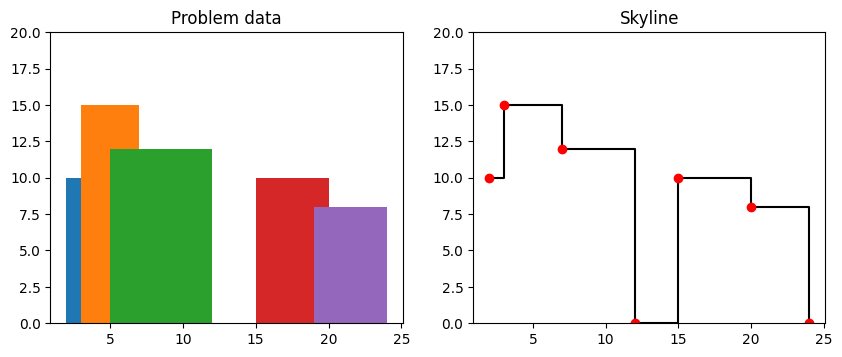

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure and a set of subplots with equal width
fig, axs = plt.subplots(1, 2, figsize=(10,5), gridspec_kw={'width_ratios': [1, 1]})

# Create the first subplot to show the problem data as colored filled rectangles
for building in example_buildings:
 left, right, height = building
 axs[0].fill([left, right, right, left], [0, 0, height, height])

axs[0].set_ylim([0, 20])
axs[0].set_aspect('equal')
axs[0].set_title('Problem data')

# Create the second subplot to plot the skyline as a staircase function
x = [x for x, _ in example_skyline]
y = [y for _, y in example_skyline]
axs[1].step(x, y, where='post', color='black')

# Add the solution points as red dots
axs[1].plot(x, y, 'ro')

axs[1].set_ylim([0, 20])
axs[1].set_aspect('equal')
axs[1].set_title('Skyline')

plt.show()


## Algorithmes à implanter

On vous demande de résoudre ce problème de 3 façons différentes :

1. En utilisant un algorithme force brute simple ;
2. En utilisant un algorithme diviser pour régner ;
3. En utilisant un algorithme diviser pour régner avec seuil de récursivité non élémentaire.

Pour l’algorithme 3, vous devrez déterminer un seuil de récursivité expérimentalement. Les exemplaires dont la taille est en deçà de ce seuil ne sont plus résolus récursivement mais plutôt directement avec l’algorithme 1.

Vos algorithmes doivent donner des réponses où les couples `(x, h)` sont triés de façon non décroissante selon x (cf. exemple plus haut). Par ailleurs, ils ne doivent pas donner de solutions avec couples redondants, i.e. deux couples qui se suivent ne peuvent pas avoir la même hauteur ni la même abscisse.


## Jeu de données

La fonction `generate_sample` ci-dessous permet de générer un exemplaire d'une taille donnée.

La fonction `get_dataset` permet de récupérer un dataset pour la liste de taille fournie. Elle prend également en entrée un graine aléatoire pour générer le dataset en question.

Afin que chaque groupe travaille avec un set différent, mais que vos propres expériences soient reproductibles, entrez l'un de vous matricule comme graine aléatoire dans la cellule ci-dessous.

Vous êtes bien entendu libres de tester et mesurer vos algorithme sur le même dataset qu'un autre groupe. Pour cela, générez simplement un dataset avec la même graine et la même liste de taille.



In [42]:
import random

max_width = 50
max_dist = 30
max_height = 300

def generate_sample(size):
    sample = []
    last_l = 0
    for _ in range(size):
        l = random.randint(last_l, last_l + max_dist)
        r = random.randint(l+1, l + max_width)
        h = random.randint(1, max_height)
        sample.append((l, r, h))
        last_l = l
    return sample

def get_dataset(seed, sizes):
    random.seed(seed)
    return { size: [generate_sample(size) for _ in range(5)]
        for size in sizes }

In [43]:
# TODO: Utilisez un de vos matricules comme graine et une liste de tailles judicieusement choisies
# On teste le cas limite 0 (liste vide), lorsqu'il y a juste 1 bâtiment (aucun tri à faire), 
# au moin une liste aux nombre pair et impair" et une grande liste (100)
# dataset = get_dataset(2218061, [0,1,10,100, 500, 1000, 5000, 10000, 20000, 50000])
dataset = get_dataset(2218061, [50, 100, 200, 500, 1000, 2000, 5000, 10000])
# dataset = get_dataset(2218061,    [1,  16   ,32, 64, 512,768,1024,4096,8192])


# Implantations et expérimentations

Ces fonctions auxiliaires vous sont fournies pour vérifier l'exactitude des vos algorithmes, mesurer leurs performance et afficher vos résultats.

Il est recommandé de prendre le temps de lire et comprendre le code.

Exécutez la cellule ci-dessous pour pouvoir utiliser les fonctions auxiliaires.

In [44]:
import matplotlib.pyplot as plt
import time
import statistics as stats

def verification_plot(buildings, skyline):
    # Create a figure and a set of subplots with equal width
    fig, ax = plt.subplots(figsize=(10,5))

    # Create the first subplot to show the problem data as colored filled rectangles
    for building in buildings:
        left, right, height = building
        ax.fill([left, right, right, left], [0, 0, height, height])

    # Create the second subplot to plot the skyline as a staircase function
    x = [x for x, _ in skyline]
    y = [y for _, y in skyline]
    ax.step(x, y, where='post', color='black')

    # Add the solution points as red dots
    ax.plot(x, y, 'ro')

    plt.show()


def measure(procedure, sample):
    """ Mesure le temps d'execution d'une procédure sur un unique exemplaire """
    start = time.time()
    solution = procedure(sample)
    end = time.time()
    sorting_time = end - start
    return solution, sorting_time


def measure_mean_time(procedure, samples):
    """ Mesure le temps moyen d'execution d'une procédure sur une liste d'exemplaires """
    total_time = 0
    for sample in samples:
        solution, compute_time = measure(procedure, sample)
        total_time += compute_time
    return total_time / len(samples)


def measure_procedure(procedure, dataset):
    """ Mesure les temps moyens d'execution d'une procédure sur chaque point d'un dataset """
    return {size: measure_mean_time(procedure, samples) for size, samples in dataset.items()}

def display_measures_table(measures):
    print("{: <12} {: <12}".format("Taille", "Temps moyen (s)"))
    for size, measure in measures.items():
        print("{: <12} {: <12}".format(size, measure))


def display_test_puissance(vals, title="Test de puissance"):
    x = list(vals.keys())
    y = list(vals.values())

    # Perform linear regression
    m, b = stats.linear_regression(x, y)

    r = list(map(lambda x : m*x + b, x))

    # Create the line equation
    line_eq = f"y = {m:.2f}x + {b:.2f}"

    # Plot the points
    plt.scatter(x, y, label='Mesures')

    # Plot the regression line
    plt.plot(x, r, color="red", label='Regression linéaire')

    # Add labels and title
    plt.xlabel('log Taille')
    plt.ylabel('log Temps')
    plt.title(title)

    # Add legend
    plt.legend(bbox_to_anchor=(0.60, 0), loc='lower left')

    # Display the line equation
    plt.text(min(x), max(y), line_eq)

    # Show the plot
    plt.show()

def display_test_rapport(vals, title="Test du rapport"):
    x = list(vals.keys())
    y = list(vals.values())

    plt.plot(x, y, label='Mesures')
    plt.scatter(x, y, label='Mesures')

    # Add labels and title
    plt.xlabel('Taille')
    plt.ylabel('Temps / f(taille)')
    plt.title(title)
    plt.show()


def display_test_constantes(vals, title="Test des constantes"):
    x = list(vals.keys())
    y = list(vals.values())

    # Perform linear regression
    m, b = stats.linear_regression(x, y)

    r = list(map(lambda x : m*x + b, x))

    # Create the line equation
    line_eq = f"y = {m:.2E}x + {b:.2E}"

    # Plot the points
    plt.scatter(x, y, label='Mesures')

    # Plot the regression line
    plt.plot(x, r, color="red", label='Regression linéaire')

    # Add labels and title
    plt.xlabel('f(Taille)')
    plt.ylabel('Temps')
    plt.title(title)

    # Add legend
    plt.legend(bbox_to_anchor=(0.60, 0), loc='lower left')

    # Display the line equation
    plt.text(min(x), max(y), line_eq)

    # Show the plot
    plt.show()


def display_mesures_seuil(vals):
    x = list(vals.keys())
    y = list(vals.values())
    plt.plot(x, y, label='Mesures')
    plt.scatter(x, y, label='Mesures')

    # Add labels and title
    plt.xlabel('Seuil')
    plt.ylabel('Temps')
    plt.title('Selection du seuil')
    plt.show()




## Algorithme naïf (brute force) (6 points)

### Implémentation (1.5 points)

TODO: Implantez un algorithme naïf pour le problème de la ligne d'horizon.

TODO: Utilisez la fonction `verification_plot` sur l'exemplaire de présentation du problème `example_buildings` pour vérifier l'exactitude de votre algorithme et laissez la figure dans votre rapport.

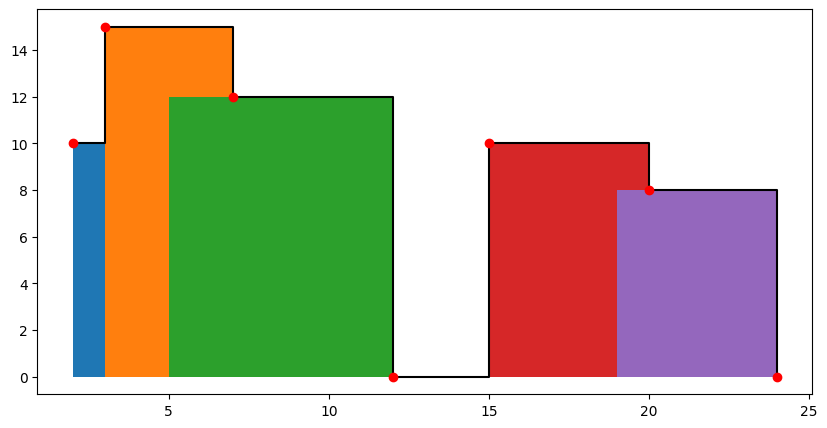

In [ ]:
def skyline_bruteforce(buildings):
    # TODO : Implantez un algorithme naïf
    # Cet algorithme est inspiré sur le code fournie par GeeksForGeeks - The Skyline Problem | Set-1
    # Lien : https://www.geeksforgeeks.org/dsa/the-skyline-problem-using-divide-and-conquer-algorithm/
    
    skyline = []
    pointsCritiques = []
    prevH = 0

    if len(buildings) == 0: 
        return skyline

    for b in buildings:
        pointsCritiques.append(b[0])
        pointsCritiques.append(b[1])
        
    pointsCritiques.sort() 

    
    for x in pointsCritiques:
        maxH = 0
        for l, r, h in buildings:
            if l <= x < r:
                maxH = max(maxH,h)
        if not skyline or maxH != prevH:
            skyline.append((x,maxH))
            prevH = maxH

    return skyline


verification_plot(example_buildings, skyline_bruteforce(example_buildings))

### Analyse asymptotique (1 points)

Quelle est la complexité asymptotique théorique de cet algorithme?

RÉPONSE : 

Nous avons la première loop de 2 opérations élémentaire append, chacune O(1) donc la boucle se fait en O(2n) = O(n).
Ensuite nous faisant un tri en nlogn qui domine jusque maintenant max(O(n),O(nlogn)).

La borne supérieure de l'algorithme complet est O(n²). En effet, soit n le nombre de bâtiments, il y a environ 2·n points critiques (car chaque bâtiment a un bord gauche et un bord droit). Pour chaque point, on effectue une vérification sur chacun des n bâtiments. Ainsi, le nombre total d’opérations nécessaires est  n × 2·n, soit O(n²) qui domine max(O(n²),O(nlogn)).

De même, on a une borne inférieur oméga de Ω(n²) aussi,car peut importe la configuration du tableau, même s'ils sont déjà tous aligés, l'algoritme parcour les 2 boucles.


La complexité est donc Θ(n²) (car borne inférieure = borne supérieure).


### Mesures (0.5 points)

In [46]:
measures_bruteforce = measure_procedure(skyline_bruteforce, dataset)

Représentez vos mesures sous forme d'un tableau avec la fonction `display_measures_table`.

In [47]:
display_measures_table(measures_bruteforce)

Taille       Temps moyen (s)
50           0.00018243789672851564
100          0.0006216526031494141
200          0.002564525604248047
500          0.015435266494750976
1000         0.057673311233520506
2000         0.23006024360656738
5000         1.4567132472991944
10000        5.787861919403076


### Analyse hybride

#### Test de puissance (1 point)

Effectuez le test de puissance de votre algorithme.

Pour cela complétez d'abord le code de la fonction `values_test_puissance` pour obtenir les valeurs à placer sur le graphe. Utilisez ensuite la fonction `display_test_puissance` pour afficher le graphe.

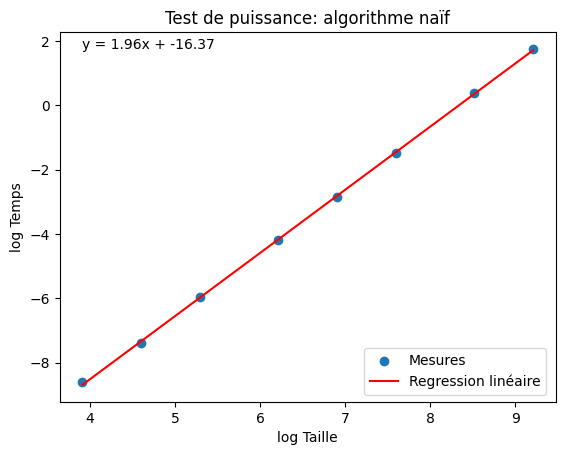

In [48]:
import math

def values_test_puissance(measures):
    return {
        math.log(size): math.log(measure)
        for size, measure in measures.items()
        if size > 0 and measure > 0
        
    }

display_test_puissance(values_test_puissance(measures_bruteforce), "Test de puissance: algorithme naïf")


Analyse du graphe obtenu pour le test de puissance.
On observe une croissance polynomiale de degré 1.96. On est donc proche d'une complexité temporelle de O(n²).

#### Test du rapport (1 point)

Effectuez le test du rapport avec une ou plusieurs fonctions f pertinentes.

Complétez d'abord la fonction `values_test_rapport` permettant d'obtenir les valeurs à reporter sur le graphe. Puis utilisez la fonction `display_test_rapport` pour afficher le graphe.

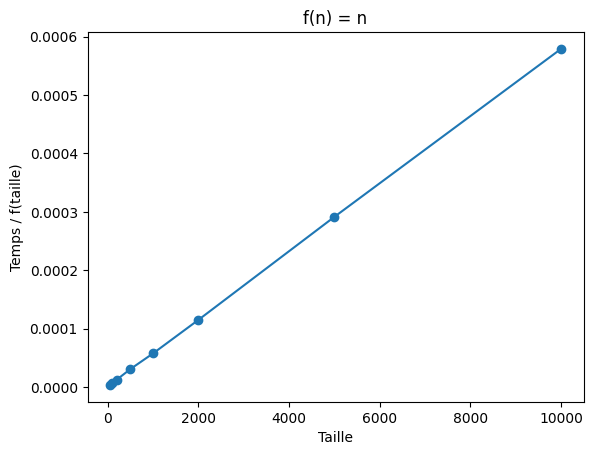

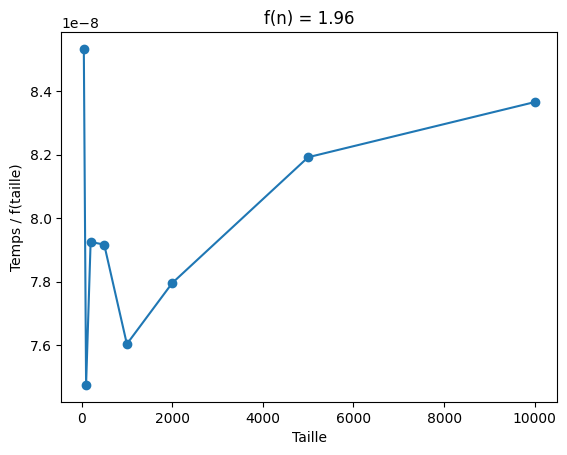

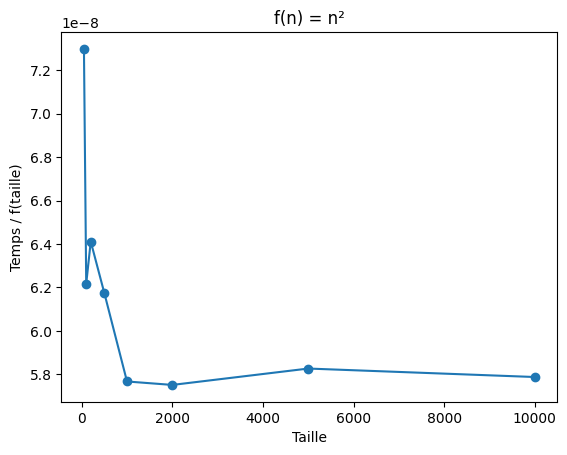

In [69]:
def values_test_rapport(measures,f):
    return {
        # TODO: calculez les valeurs pour le test du rapport
        size: measure / f(size)
        for size, measure in measures.items()
        if f(size) != 0 and size>=1
    }

# TODO: definissez f judicieusement
def f(x):
    return  x
def f1(x):
    return  pow(x, 1.96)
def f2(x):
    return  pow(x, 2)

#test avec f(x) = x
display_test_rapport(values_test_rapport(measures_bruteforce, f),"f(n) = n")

#test avec f(x) = x^2
display_test_rapport(values_test_rapport(measures_bruteforce, f1),"f(n) = 1.96")
display_test_rapport(values_test_rapport(measures_bruteforce, f2),"f(n) = n²")

Anayse du graphe obtenu pour le test du rapport. Précisez le critère de choix de votre ou vos fonctions.

Étant donné que l'analyse asymptotique était O(n²), on teste avec f(n) = n². Puisque ça nous donne une surestimation, on test avec f(n) = n et la valeur obtenu au test de puissance soit n^1.96.

- Avec le test du rapport, avec f(n) = n, on sous-estime
- Avec le test du rapport, avec f(n) = n^(1.96), on semble converger
- Avec le test du rapport, avec f(n) = n² on surestime

Notre compléxité est certainement superieur à n et inférieur a n² mais tend vers ce deuxième.

### Test des constantes (1 point)

Effectuez le test des constantes avec une ou plusieurs fonctions f pertinentes.

Complétez d'abord la fonction `values_test_constantes` permettant d'obtenir les valeurs à reporter sur le graphe. Puis utilisez la fonction `display_test_constantes` pour afficher le graphe.

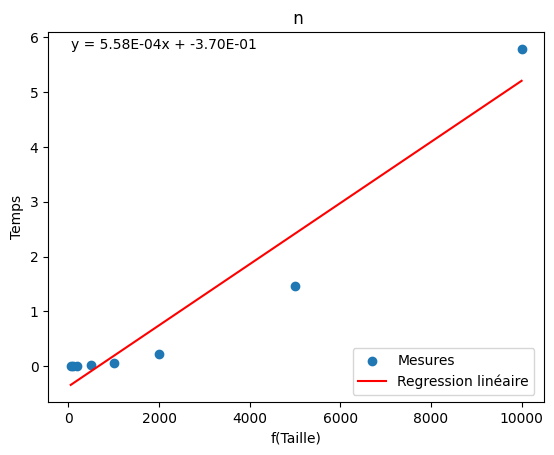

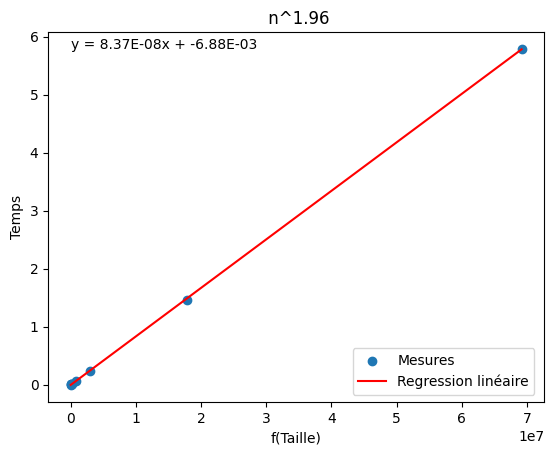

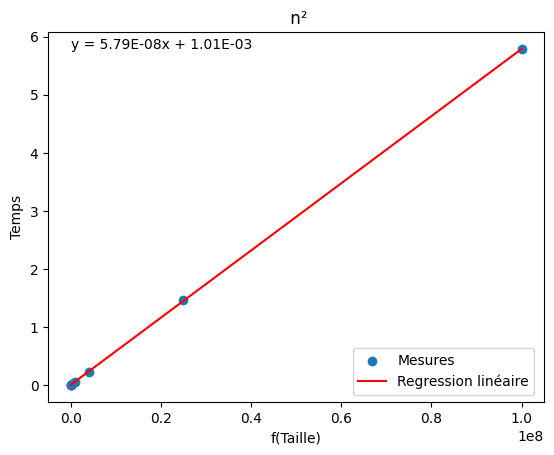

In [71]:
def values_test_constantes(measures, f):
    return {
        f(size): measure
        for size, measure in measures.items()
    }

display_test_constantes(values_test_constantes(measures_bruteforce, f)," n" )
display_test_constantes(values_test_constantes(measures_bruteforce, f1)," n^1.96" )
display_test_constantes(values_test_constantes(measures_bruteforce, f2)," n²" )

Indiquez les valeurs des constantes mises en évidence par le test.

On observe bien une droite pour n^1.96 et n² avec 
- pour n^1.96  c = 8,377 × 10⁻⁸ et b = - 6.88 × 10⁻³
- pour n²   c = 5,79 × 10⁻⁸ et b = 1.01 × 10⁻³

Pour n,  c = 5,58 × 10⁻⁴ et b = -3.70 × 10⁻1 mais ne suit pas de droite.



## Algorithme diviser pour régner (6 points)


### Implémentation (1.5 points)

TODO: Implantez un algorithme pour le problème de la ligne d'horizon utlisant le patron de conception "Diviser pour régner".

Il est conseillé de prévoir un paramètre pour le seuil de récursivité (e.g. `threshold`), en dessous duquel, vous utiliserez l'algorithme naïf écrit précédemment. Dans ce cas, le seuil devrait être 1.

In [ ]:
# Généré par ChatGPT
def skyline_divide_and_conquer(buildings, threshold=1):
    """
    Compute the skyline using divide and conquer with a threshold for naive solution.
    """
    if not buildings:
        return []
    
    if len(buildings) <= threshold:
        return skyline_bruteforce(buildings)

    # if len(buildings) == 1:
    #     left, right, height = buildings[0]
    #     return [[left, height], [right, 0]]
    
    # Divide: split buildings into left and right halves
    mid = len(buildings) // 2
    left_skyline = skyline_divide_and_conquer(buildings[:mid], threshold)
    right_skyline = skyline_divide_and_conquer(buildings[mid:], threshold)
    
    # Conquer: merge the two skylines
    return merge_skylines(left_skyline, right_skyline)


def merge_skylines(left, right):
    """
    Merge two skylines using a two-pointer approach.
    """
    result = []
    i = j = 0
    h_left = h_right = 0  # Current heights from each skyline
    n, m = len(left), len(right)
    
    while i < n and j < m:
        x1, height1 = left[i]
        x2, height2 = right[j]
        
        if x1 < x2:
            h_left = height1
            current_height = max(h_left, h_right)
            add_skyline_point(result, x1, current_height)
            i += 1
        elif x2 < x1:
            h_right = height2
            current_height = max(h_left, h_right)
            add_skyline_point(result, x2, current_height)
            j += 1
        else:  # x1 == x2
            h_left = height1
            h_right = height2
            current_height = max(h_left, h_right)
            add_skyline_point(result, x1, current_height)
            i += 1
            j += 1
    
    # Add remaining points from left skyline
    while i < n:
        add_skyline_point(result, left[i][0], left[i][1])
        i += 1
    
    # Add remaining points from right skyline
    while j < m:
        add_skyline_point(result, right[j][0], right[j][1])
        j += 1
    
    return result


def add_skyline_point(skyline, x, height):
    """
    Add a point to the skyline only if it changes the height.
    Prevents duplicate points with the same height.
    """
    if not skyline:
        skyline.append([x, height])
    else:
        last_x, last_height = skyline[-1]
        if height != last_height:
            # If same x-coordinate, update the height instead of adding new point
            if x == last_x:
                skyline[-1][1] = max(skyline[-1][1], height)
            else:
                skyline.append([x, height])



TODO: Utilisez la fonction `verification_plot` sur l'exemplaire de présentation du problème `example_buildings` pour vérifier l'exactitude de votre algorithme et laissez la figure dans votre rapport.

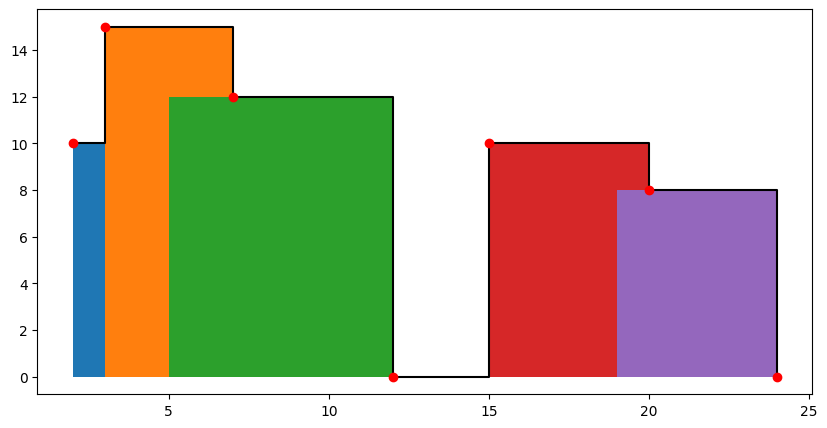

In [52]:
def skyline_divide_and_conquer_naive_threshold(buildings):
    # TODO diviser pour régner avec un seuil de récursivité de 1
    skyline_divide_and_conquer(buildings, 1)
    return []
verification_plot(example_buildings, skyline_divide_and_conquer(example_buildings,1))

### Analyse asymptotique (1 points)

TODO: Quelle est la complexité asymptotique théorique de cet algorithme?

Nous avons 3 fonctions, le divide and conquer, le merge et et le add skyline points. On calcule la première avec le Master theorème. 
- Le add_skyline_points est constitué de 2 branchements, tout 2 en O(1), utilisant des opérations élémentaire comme append, max et accéder au dernier index, donc theta(1).
- Le merge a 3 boucle while, ayant chacune un theta(n), étant des boucles faisant des opérations élémentaires ou add_skyline_points O(1). Donc O(3n) => O(n)

Selon le Master Théorème, "T(n) = lT (n/b) + cnk" où 
- l = 2 appels récursifs
- b = 2 puisque nous divisons en 2 sous ensembles de même taille
- k = 1 puisque que la partie du "merge" se fait en O(n)
- On a alors l = b^k  => 2 = 2 => on est sur du n^k log(n) 

nous avons alors pour T(n)=2T(n/2) + cn  un theta de **nlog(n)**


### Mesures (0.5 points)

In [53]:
measures_divide_naive_threshold = measure_procedure(skyline_divide_and_conquer_naive_threshold, dataset)
display_measures_table(measures_divide_naive_threshold)

Taille       Temps moyen (s)
50           0.0001437664031982422
100          0.0002781391143798828
200          0.0008957862854003906
500          0.0018793582916259766
1000         0.0035256385803222657
2000         0.007541131973266601
5000         0.02976069450378418
10000        0.04334201812744141


### Analyse hybride

#### Test de puissance (1 point)

Effectuez le test de puissance de votre algorithme.

Utilisez la fonction `display_test_puissance` pour afficher le graphe.

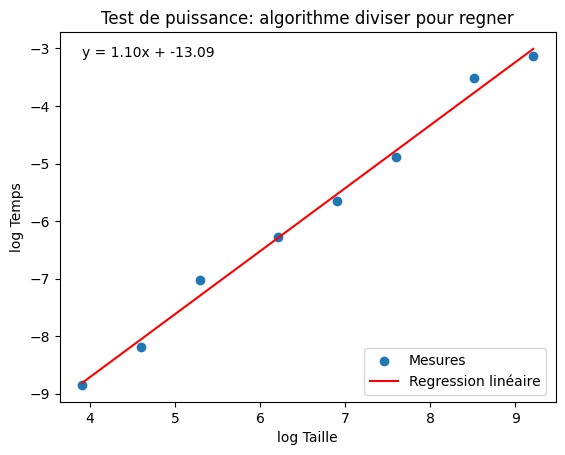

In [54]:
display_test_puissance(values_test_puissance(measures_divide_naive_threshold), "Test de puissance: algorithme diviser pour regner")

TODO: Analysez le graphe obtenu pour le test de puissance.

On obtient un coefficient un peu superieur à 1, indiquant donc une croissance polynomiale.

#### Test du rapport (1 point)

Effectuez le test du rapport avec une ou plusieurs fonctions f pertinentes.

Utilisez la fonction `display_test_rapport` pour afficher le graphe.

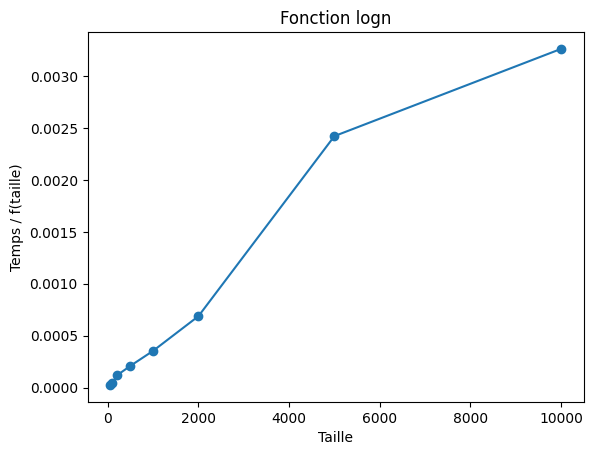

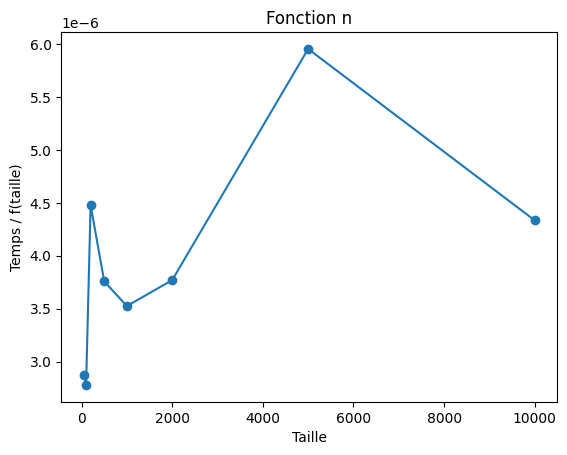

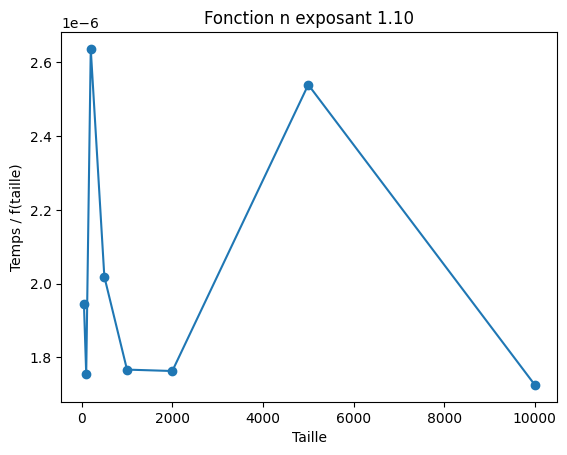

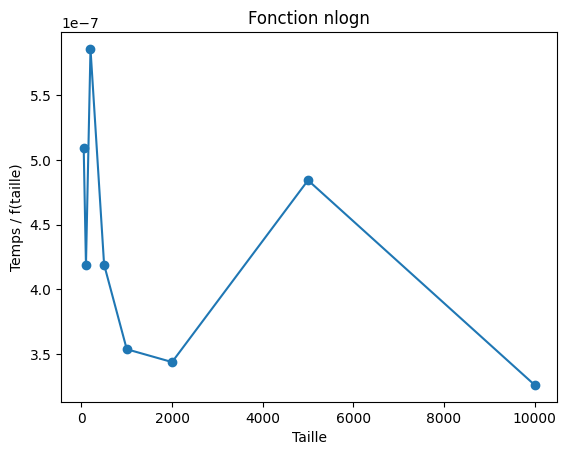

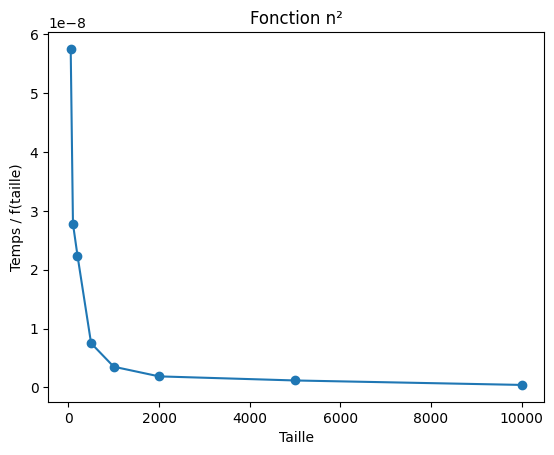

In [72]:
# TODO: définissez f judicieusement
def flog(x):
    return math.log(x,2) #log(n)
def fn(x): # n
    return x
def f1(x):
    return pow(x,1.10)
def fnlogn(x):
    return math.log(x,2)*x #nlog(n)
def fn2(x):
    return pow(x,2) #n²

display_test_rapport(values_test_rapport(measures_divide_naive_threshold, flog),"Fonction logn")
display_test_rapport(values_test_rapport(measures_divide_naive_threshold, fn),"Fonction n")
display_test_rapport(values_test_rapport(measures_divide_naive_threshold, f1),"Fonction n exposant 1.10")
display_test_rapport(values_test_rapport(measures_divide_naive_threshold, fnlogn),"Fonction nlogn")
display_test_rapport(values_test_rapport(measures_divide_naive_threshold, fn2),"Fonction n²")

TODO: Analysez le graphe obtenu pour le test du rapport.

- Avec le test du rapport, avec f(n) = log(n), on sous-estime
- Avec le test du rapport, avec f(n) = n et n^(1.10), on semble converger
- Avec le test du rapport, avec f(n) = n² et nlnog(n) on surestime

Notre compléxité est certainement superieur a log(n) et inférieur a n²

### Test des constantes (1 point)

Effectuez le test des constantes avec une ou plusieurs fonctions f pertinentes.

Utilisez la fonction `display_test_constantes` pour afficher le graphe.

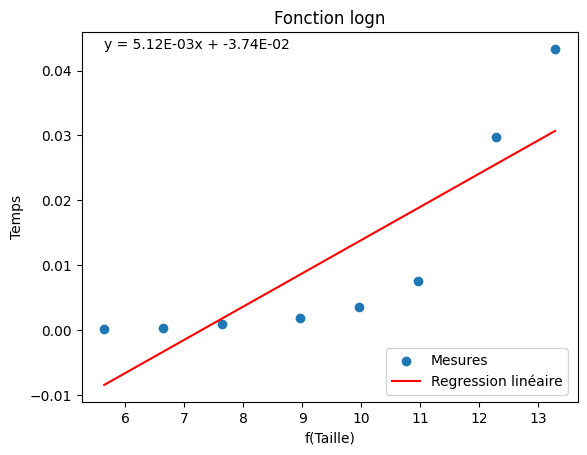

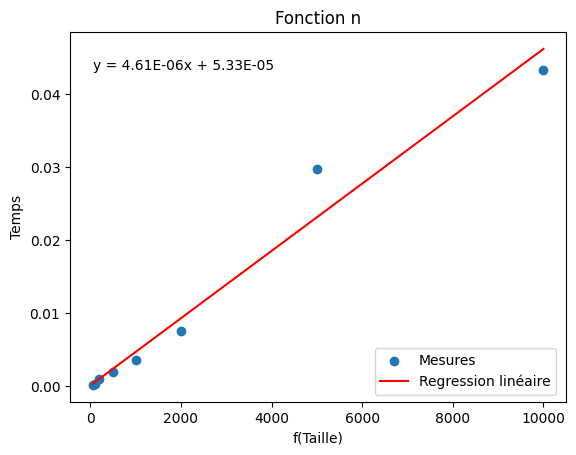

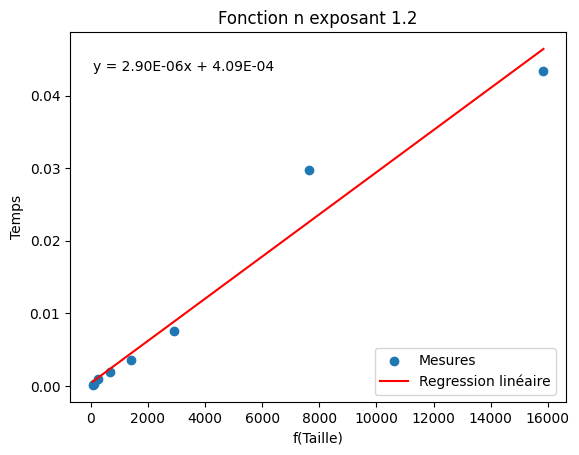

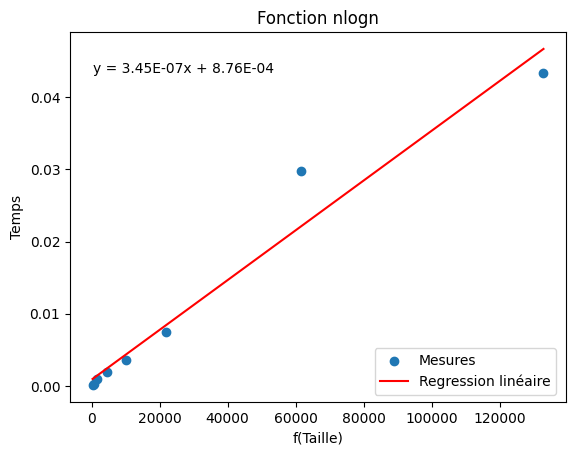

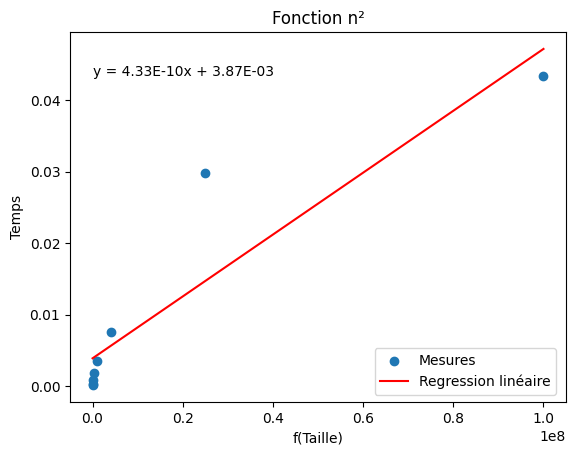

In [56]:
# TODO: définissez f judicieusement

def flog(x):
    return math.log(x,2) #log(n)
def fn(x): # n
    return x
def f1(x):
    return pow(x,1.05)
def fnlogn(x):
    return math.log(x,2)*x #nlog(n)
def fn2(x):
    return pow(x,2) #n²

display_test_constantes(values_test_constantes(measures_divide_naive_threshold, flog),"Fonction logn")
display_test_constantes(values_test_constantes(measures_divide_naive_threshold, fn),"Fonction n")
display_test_constantes(values_test_constantes(measures_divide_naive_threshold, f1),"Fonction n exposant 1.2")
display_test_constantes(values_test_constantes(measures_divide_naive_threshold, fnlogn),"Fonction nlogn")
display_test_constantes(values_test_constantes(measures_divide_naive_threshold, fn2),"Fonction n²")

TODO: Indiquez les valeurs des constantes mises en évidence par le test.

| Fonction      | Valeur              |
|---------------|---------------------|
| log(n)        | m= 5.12E-03 b= -3.74E-02|
| n             | m= 4.61E-06 b= 5.33E-05|
| eposant x1.10 | m= 2.90E-06 b= 4.09E-04|
| n log(n)      | m= 3.45E-07 b= 8.76E-04|
| n²            | m= 4.33E-10 b= 3.87E-03|

## Algorithme diviser pour régner (seuil choisi) (6 points)

### Sélection du seuil (1.5 points)

In [ ]:

thresholds = [1, 2,3, 4,5,6,7, 8, 12, 16, 32, 128]
[print(t) for t in thresholds]
measures_threshold = {
    i:
    measure_mean_time(
        lambda sample: skyline_divide_and_conquer(sample, i),[generate_sample(64)]) # TODO: sélectionnez un exemplaire
        for i in thresholds # TODO: testez une liste judicieuse de seuils
}

1
2
3
4
5
6
7
8
12
16
32
128


Effectuez les mesures avec plusieurs seuils de récursivité pour déterminer le seuil le plus judicieux.

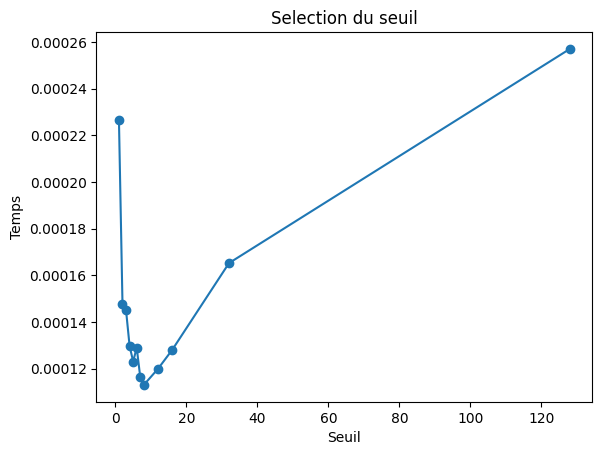

In [58]:

display_mesures_seuil(measures_threshold)


Quel est le seuil de récursivité de le plus judicieux ? Sur quel critère l'avez vous sélectionné ?

L'analyse sur de petits seuils (1–50) montre que le temps d’exécution est petit pour un seuil très faible, autour de 8. Lorsque le seuil augmente, les performances diminuent. Le seuil optimal est 8.

Nous nous somme basé sur le critère de complexité asymptotique du code. Il fallait qu'on trouve l'équilibre entre le coût quadratique du skyline_bruteforce (≈ O(n²)) et le coût de merge (≈ O(n)). On a donc choisit de mettre le seuil très petit, car si c'est trop grand, la complexité quadratique domine grandement. 

TODO: Utilisez votre fonction générique pour implanter un algorithme avec le seuil choisi.

TODO: Utilisez la fonction `verification_plot` sur l'exemplaire de présentation du problème `example_buildings` pour vérifier l'exactitude de votre algorithme et laissez la figure dans votre rapport.

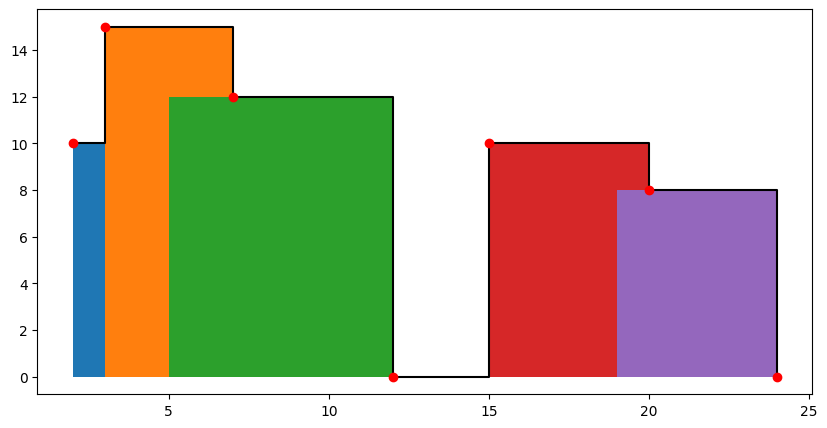

In [59]:
def skyline_divide_and_conquer_best_threshold(buildings):
    # TODO diviser pour régner avec un seuil de récursivité de n
    return skyline_divide_and_conquer(buildings, 8)

verification_plot(example_buildings,skyline_divide_and_conquer_best_threshold(example_buildings))

### Analyse asymptotique (1 points)

Quelle est la complexité asymptotique théorique de cet algorithme?

Ici, on ajoute un branchement conditionnel où la récursion est évité en dessous du seuil choisi. 
En dessous du seuil, on a une complexité de O(n²) et au dessus on O(nlogn). 

Maintenant, on sait que la complexité de bruteforce, seuil=8 sera au plus de O(64) donc une constante alors que le reste de l'algoithme continue avec n tend vers l'infini. Alors, l'algorithme maintient une complexité de nlogn.

### Mesures (0.5 points)

In [60]:
measures_divide_best_threshold = measure_procedure(skyline_divide_and_conquer_best_threshold,dataset)

In [76]:
display_measures_table(measures_divide_best_threshold)

Taille       Temps moyen (s)
50           9.584426879882812e-05
100          0.00019621849060058594
200          0.00042748451232910156
500          0.003295421600341797
1000         0.0040008544921875
2000         0.005647516250610352
5000         0.01592698097229004
10000        0.0445404052734375


### Analyse hybride

#### Test de puissance (1 point)

Effectuez le test de puissance de votre algorithme.

Utilisez la fonction `display_test_puissance` pour afficher le graphe.

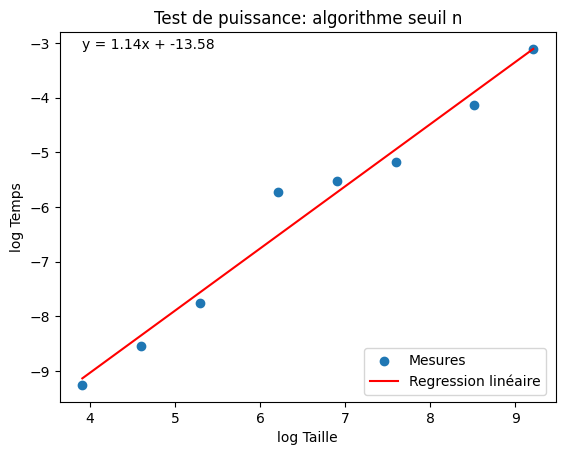

In [62]:
display_test_puissance(values_test_puissance(measures_divide_best_threshold), "Test de puissance: algorithme seuil n")

Analysez le graphe obtenu pour le test de puissance.

On obtient une ligne droite avec une pente assez proche de celle obtenu par le test de puissance pour l'algorithme diviser pour régner avec seuil=1.

#### Test du rapport (1 point)

Effectuez le test du rapport avec une ou plusieurs fonctions f pertinentes.

Utilisez la fonction `display_test_rapport` pour afficher le graphe.

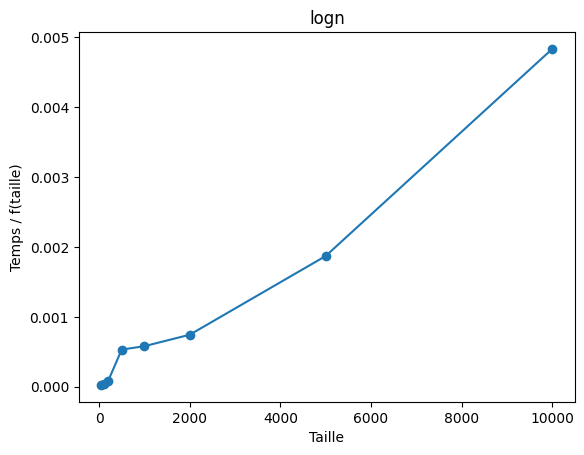

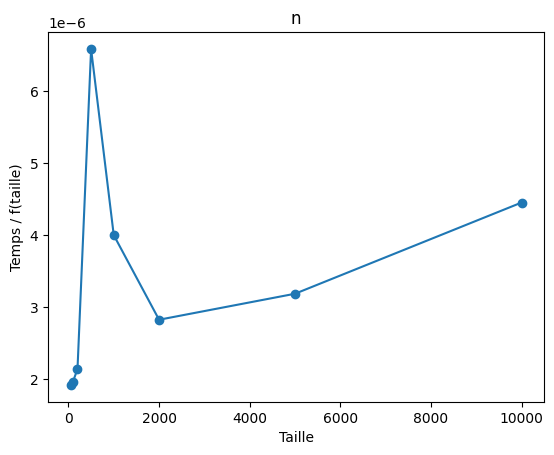

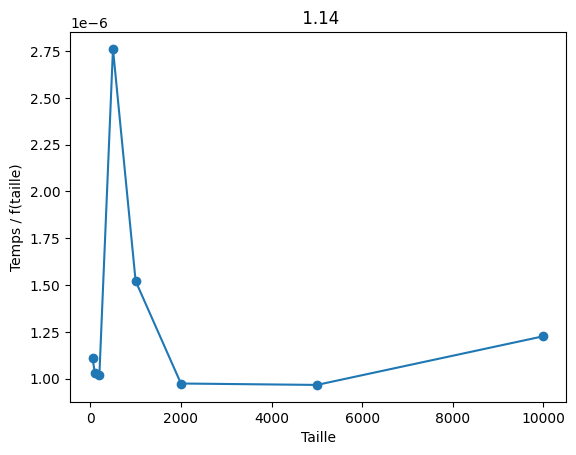

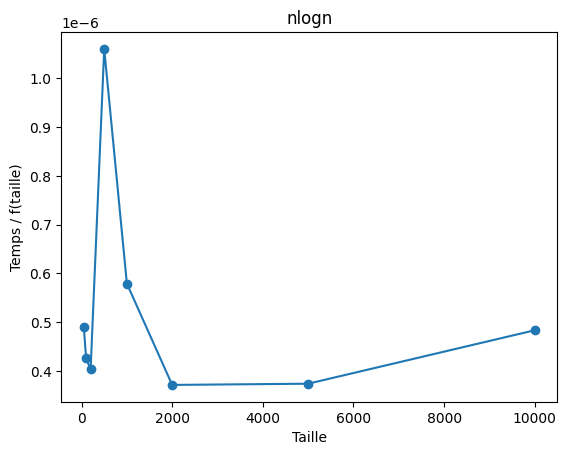

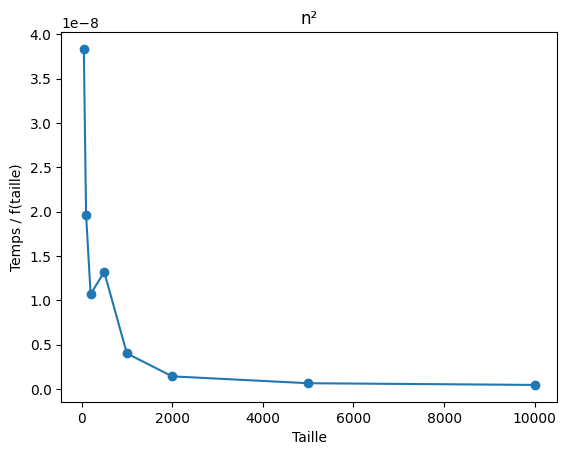

In [74]:
# TODO: définissez f judicieusement

def flog(x):
    return math.log(x) #log(n)
def fn(x): # n
    return x
def f1(x):
    return pow(x,1.14)
def fnlogn(x):
    return math.log(x)*x #nlog(n)
def fn2(x):
    return pow(x,2) #n²


display_test_rapport(values_test_rapport(measures_divide_best_threshold, flog),"logn")
display_test_rapport(values_test_rapport(measures_divide_best_threshold, fn),"n")
display_test_rapport(values_test_rapport(measures_divide_best_threshold, f1)," 1.14")
display_test_rapport(values_test_rapport(measures_divide_best_threshold, fnlogn),"nlogn")
display_test_rapport(values_test_rapport(measures_divide_best_threshold, fn2),"n²")


Analysez le graphe obtenu pour le test du rapport

Ressemble majoritairement au cas avec seuil =1 mais tout les graphes sont moins lisses, avec log(n) qui sous-estime et n² qui surestime

### Test des constantes (1 point)

Effectuez le test des constantes avec une ou plusieurs fonctions f pertinentes.

Utilisez la fonction `display_test_constantes` pour afficher le graphe.

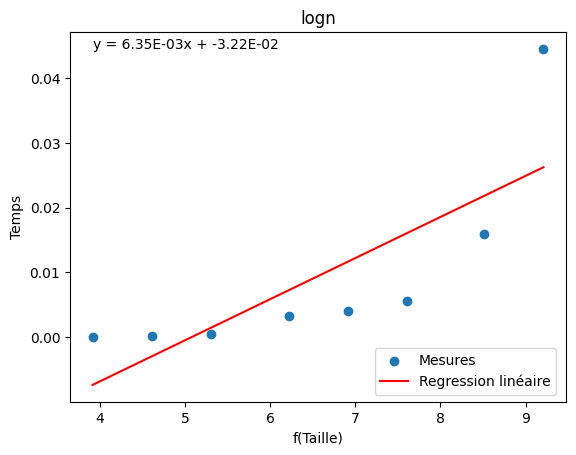

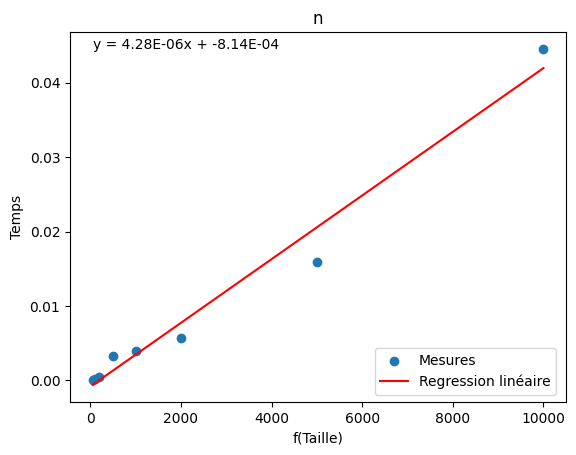

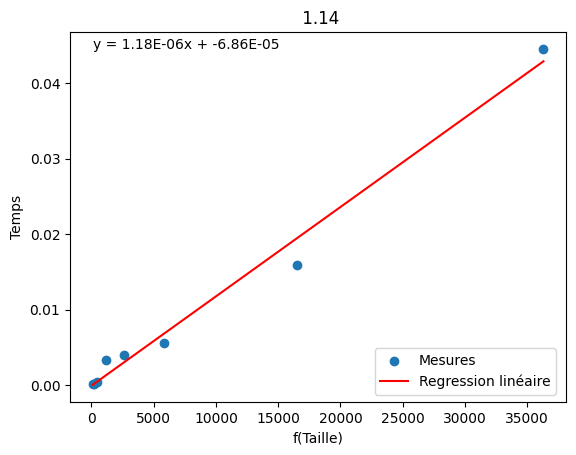

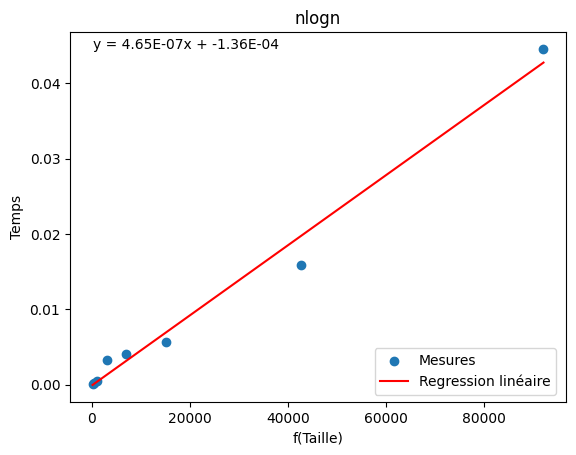

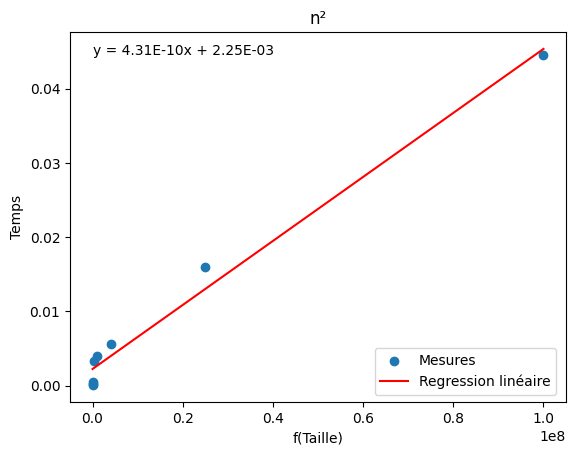

In [75]:
# TODO: définissez f judicieusement

display_test_constantes(values_test_constantes(measures_divide_best_threshold, flog),"logn")
display_test_constantes(values_test_constantes(measures_divide_best_threshold, fn),"n")
display_test_constantes(values_test_constantes(measures_divide_best_threshold, f1)," 1.14")
display_test_constantes(values_test_constantes(measures_divide_best_threshold, fnlogn),"nlogn")
display_test_constantes(values_test_constantes(measures_divide_best_threshold, fn2),"n²")

Indiquez les valeurs des constantes mises en évidence par le test.

| Fonction      | constante     |
|---------------|------------|
| log(n)        | m= 6.35E-03 b= -3.22E-02|
| n             | m= 4.28E-06 b= -8.14E-04|
| eposant x1.14 | m= 1.18E-06 b= -6.86E-05|
| n log(n)      | m= 4.65E-07 b= 1.36E-04|
| n²            | m= 4.31E-10 b= 2.25E-03|

# Conclusion (2 points)


Commentez l'impact du seuil de récursivité. Que représente t'il pour l'algorithme diviser pour régner et l'algorithme naïf ?
Le choix d'un bon seuil de récursivité a un grand impact dans l'alogrithme diviser pour regner et naif. En effet, pour des tailles de données en dessus du seuil de récursivité, il est préférable d'utiliser l'algorithme naif, car on évite de faire des opérations additionelle de récursion comme la fusion et séparation de tableau qui affecterait les performances. Par contre, une fois cette valeur dépassée,il devient plus avantageux d’exécuter l’algorithme diviser pour régner, car sa complexité asymptotique est meilleure que celle de l’algorithme naïf.

En vous basant sur vos résultats, résumez vos découvertes et analyses, et indiquez dans quelles circonstances vous utiliserez chacun de ces 3 algorithmes en démontrant leurs points forts et point faibles.

| Taille | Temps moyen (ms) bruteforce | Temps moyen (ms) seuil=1 | Temps moyen (ms) seuil=8 |
|--------|-----------------------------|----------------------|----------------------|
| 1      | 0.00134                     | 0.00143              | 0.00143             |
| 16     | 0.02208                     | 0.03972              | 0.021839              |
| 32     | 0.07238                     | 0.07863              | 0.04925              |
| 64     | 0.27027                     | 0.16379              | 0.12081              |
| 512    | 14.98532                    | 1.64342              | 1.20735              |
| 768    | 33.55470                    | 2.52395              | 3.00641              |
| 1024   | 59.22575                    | 3.35855              | 2.54955              |
| 4096   | 952.29902                   | 17.68584             | 12.0453             |
| 8192   | 3791.74986                  | 42.08269             | 36.74225             |



| Taille | Temps moyen (ms) bruteforce | Temps moyen (ms) seuil=1 | Temps moyen (ms) seuil=8 |
|--------|----------------------------|--------------------------|--------------------------|
| 50     | 0.18244                    | 0.14377                  | 0.09584                  |
| 100    | 0.62165                    | 0.27814                  | 0.19622                  |
| 200    | 2.56453                    | 0.89579                  | 0.42748                  |
| 500    | 15.43527                   | 1.87936                  | 3.29542                  |
| 1000   | 57.67331                   | 3.52564                  | 4.00085                  |
| 2000   | 230.06024                  | 7.54113                  | 5.64752                  |
| 5000   | 1456.71325                 | 29.76069                 | 15.92698                 |
| 10000  | 5787.86192                 | 43.34202                 | 44.54041                 |


Il y a des raisons à utiliser l'algorithme bruteforce seul par exemple avec des exemplaires assez petit (On peut voir qu'il est performant avec n<=32 à peu près) ou que la longueur du code lui-même soient le facteur limitant et la consommation de mémoire des appels récursif soient un problème.

Pour diviser pour régner avec seuil=1, nous ne voyons pas de raison de l'utiliser. Le temps d'éxecution est plus long à partir de n=1.


 ## Autres critères


Présentation générale / -
1 pt

- Concision
- Qualité du français

Pénalité retard
- -1 pt / journée de retard, arrondi vers le haut. Les TPs ne sont plus acceptés après 3 jours.